In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import random
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# Cấu hình thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
PAD_token = 0
SOS_token = 1
EOS_token = 2

class Vocabulary:
    def __init__(self, name):
        self.name = name
        self.word2index = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2}
        self.word2count = {}
        self.index2word = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>"}
        self.n_words = 3

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word.lower())

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

def load_data(vi_path, en_path, num_samples=20000):
    with open(vi_path, 'r', encoding='utf-8') as f:
        vi_lines = f.read().split('\n')
    with open(en_path, 'r', encoding='utf-8') as f:
        en_lines = f.read().split('\n')
    
    pairs = [[vi.strip(), en.strip()] for vi, en in zip(vi_lines[:num_samples], en_lines[:num_samples]) if vi and en]
    return pairs

# Đường dẫn dữ liệu
vi_path = r'd:\dut_ai\AIO_code\Attention\data\archive\vi_sents'
en_path = r'd:\dut_ai\AIO_code\Attention\data\archive\en_sents'

pairs = load_data(vi_path, en_path)
input_lang = Vocabulary('vi')
output_lang = Vocabulary('en')

for pair in pairs:
    input_lang.addSentence(pair[0])
    output_lang.addSentence(pair[1])

print(f"Từ điển VI: {input_lang.n_words} | Từ điển EN: {output_lang.n_words}")

Từ điển VI: 5338 | Từ điển EN: 11277


In [4]:
# Chia dữ liệu Train/Val
train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)}")

Train: 16000 | Val: 4000


In [5]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.gru = nn.GRU(emb_dim, hid_dim, batch_first=True)
        
    def forward(self, input):
        embedded = self.embedding(input)
        outputs, hidden = self.gru(embedded)
        return outputs, hidden

class BahdanauAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.Wa = nn.Linear(hid_dim, hid_dim)
        self.Ua = nn.Linear(hid_dim, hid_dim)
        self.Va = nn.Linear(hid_dim, 1)

    def forward(self, query, values):
        query = query.transpose(0, 1)
        score = self.Va(torch.tanh(self.Wa(query) + self.Ua(values)))
        attention_weights = F.softmax(score, dim=1)
        context_vector = torch.bmm(attention_weights.transpose(1, 2), values)
        return context_vector, attention_weights

class AttnDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim):
        super().__init__()
        self.attention = BahdanauAttention(hid_dim)
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.gru = nn.GRU(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        embedded = self.embedding(input)
        context_vector, attn_weights = self.attention(hidden, encoder_outputs)
        input_gru = torch.cat((embedded, context_vector), dim=2)
        output, hidden = self.gru(input_gru, hidden)
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden, attn_weights

In [6]:
def evaluate_metrics(encoder, decoder, pairs, criterion):
    encoder.eval()
    decoder.eval()
    total_loss = 0
    total_correct = 0
    total_tokens = 0
    
    def sentence_to_tensor(lang, sentence):
        indexes = [lang.word2index.get(word.lower(), 0) for word in sentence.split(' ')]
        indexes.append(EOS_token)
        return torch.tensor([indexes], dtype=torch.long, device=device)

    with torch.no_grad():
        for pair in pairs:
            input_tensor = sentence_to_tensor(input_lang, pair[0])
            target_tensor = sentence_to_tensor(output_lang, pair[1])
            target_length = target_tensor.size(1)
            
            encoder_outputs, encoder_hidden = encoder(input_tensor)
            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden
            
            for di in range(target_length):
                decoder_output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs)
                loss = criterion(decoder_output, target_tensor[:, di])
                total_loss += loss.item()
                
                topi = decoder_output.data.topk(1)[1]
                if topi.item() == target_tensor[:, di].item():
                    total_correct += 1
                total_tokens += 1
                decoder_input = target_tensor[:, di].unsqueeze(1)
                
    return total_loss / (len(pairs) * target_length), total_correct / total_tokens

def train_step(input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion):
    encoder.train()
    decoder.train()
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()
    
    target_length = target_tensor.size(1)
    loss = 0
    correct = 0
    
    encoder_outputs, encoder_hidden = encoder(input_tensor)
    decoder_input = torch.tensor([[SOS_token]], device=device)
    decoder_hidden = encoder_hidden
    
    for di in range(target_length):
        decoder_output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs)
        loss += criterion(decoder_output, target_tensor[:, di])
        
        topi = decoder_output.data.topk(1)[1]
        if topi.item() == target_tensor[:, di].item():
            correct += 1
            
        decoder_input = target_tensor[:, di].unsqueeze(1) 

    loss.backward()
    encoder_optimizer.step()
    decoder_optimizer.step()
    
    return loss.item() / target_length, correct / target_length

def train_model(encoder, decoder, n_epochs, train_pairs, val_pairs):
    def sentence_to_tensor(lang, sentence):
        indexes = [lang.word2index.get(word.lower(), 0) for word in sentence.split(' ')]
        indexes.append(EOS_token)
        return torch.tensor([indexes], dtype=torch.long, device=device)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(1, n_epochs + 1):
        epoch_train_loss = 0
        epoch_train_acc = 0
        
        progress_bar = tqdm(train_pairs, desc=f"Epoch {epoch}")
        for pair in progress_bar:
            input_tensor = sentence_to_tensor(input_lang, pair[0])
            target_tensor = sentence_to_tensor(output_lang, pair[1])
            
            loss, acc = train_step(input_tensor, target_tensor, encoder, decoder, 
                                 encoder_optimizer, decoder_optimizer, criterion)
            epoch_train_loss += loss
            epoch_train_acc += acc
            progress_bar.set_postfix(loss=f"{loss:.4f}", acc=f"{acc:.4f}")
            
        val_loss, val_acc = evaluate_metrics(encoder, decoder, val_pairs, criterion)
        
        avg_train_loss = epoch_train_loss / len(train_pairs)
        avg_train_acc = epoch_train_acc / len(train_pairs)
        
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"-> [Epoch {epoch}] Train Loss: {avg_train_loss:.4f} | Acc: {avg_train_acc:.4f} || Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f}\n")
        
    return history

In [7]:
def evaluate_and_plot(encoder, decoder, sentence, max_length=20):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        input_indices = [input_lang.word2index.get(word.lower(), 0) for word in sentence.split(' ')] + [EOS_token]
        input_tensor = torch.tensor([input_indices], device=device)
        
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden
        
        decoded_words = []
        decoder_attentions = torch.zeros(max_length, input_tensor.size(1))
        
        for di in range(max_length):
            decoder_output, decoder_hidden, attn_weights = decoder(decoder_input, decoder_hidden, encoder_outputs)
            decoder_attentions[di] = attn_weights.squeeze()
            
            topi = decoder_output.data.topk(1)[1]
            if topi.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            else:
                decoded_words.append(output_lang.index2word[topi.item()])
            decoder_input = topi.detach()

        # Visualize Attention
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111)
        cax = ax.matshow(decoder_attentions[:len(decoded_words), :].cpu().numpy(), cmap='bone')
        fig.colorbar(cax)
        ax.set_xticklabels([''] + sentence.split(' ') + ['<EOS>'], rotation=90)
        ax.set_yticklabels([''] + decoded_words)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
        plt.show()
        return " ".join(decoded_words)

In [8]:
HIDDEN_DIM = 256
EMBEDDING_DIM = 128

encoder = Encoder(input_lang.n_words, EMBEDDING_DIM, HIDDEN_DIM).to(device)
decoder = AttnDecoder(output_lang.n_words, EMBEDDING_DIM, HIDDEN_DIM).to(device)

encoder_optimizer = optim.Adam(encoder.parameters(), lr=0.001)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

# Chạy huấn luyện
history = train_model(encoder, decoder, n_epochs=3, train_pairs=train_pairs, val_pairs=val_pairs)

# Vẽ biểu đồ kết quả
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_title('Loss Curve')
ax1.legend()

ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'], label='Val Acc')
ax2.set_title('Accuracy Curve')
ax2.legend()

plt.show()

Epoch 1:  34%|███▍      | 5485/16000 [33:05<1:03:26,  2.76it/s, acc=0.2727, loss=5.7084] 


KeyboardInterrupt: 

--- Kiểm tra dịch trên tập Validation ---
VI: Tôi đang cố gắng trở thành một chuyên gia sử dụng rìu.
Target: I'm trying to become an expert in using axes.


C:\Users\khacb\AppData\Local\Temp\ipykernel_15448\488776757.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence.split(' ') + ['<EOS>'], rotation=90)
C:\Users\khacb\AppData\Local\Temp\ipykernel_15448\488776757.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + decoded_words)


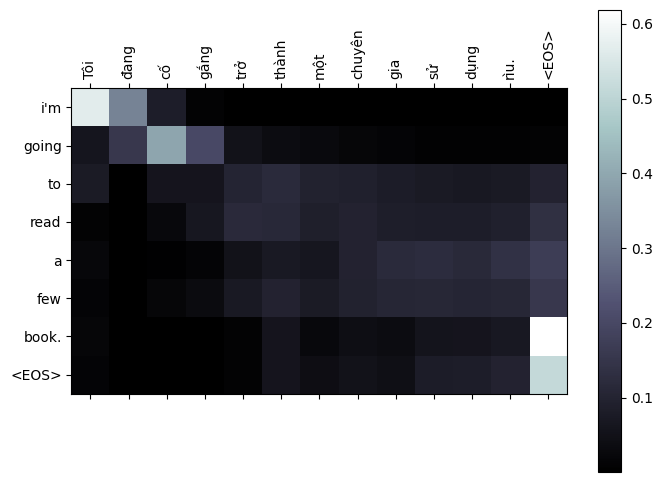

Predict: i'm going to read a few book. <EOS>

VI: Tom muốn tôi nói với bạn rằng anh ấy không thể đến hôm nay.
Target: Tom wanted me to tell you he can't come today.


C:\Users\khacb\AppData\Local\Temp\ipykernel_15448\488776757.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence.split(' ') + ['<EOS>'], rotation=90)
C:\Users\khacb\AppData\Local\Temp\ipykernel_15448\488776757.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + decoded_words)


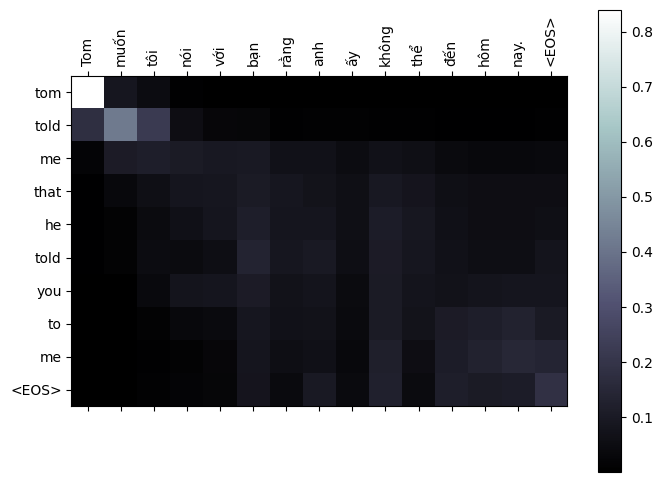

Predict: tom told me that he told you to me <EOS>



In [9]:
print("--- Kiểm tra dịch trên tập Validation ---")
for i in range(2):
    sample = random.choice(val_pairs)
    print(f"VI: {sample[0]}")
    print(f"Target: {sample[1]}")
    output = evaluate_and_plot(encoder, decoder, sample[0])
    print(f"Predict: {output}\n")